In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed dataset
df = pd.read_csv('/content/drive/MyDrive/std_dropout_prediction_project/Cleaned_Dataset_For_Modeling.csv')

# Decode Target_Encoded back to strings for easier interpretation
target_map_reverse = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
df['Target'] = df['Target_Encoded'].map(target_map_reverse)

print(f"Dataset loaded. Shape: {df.shape}")
print(f"Target distribution:\n{df['Target'].value_counts()}")



Dataset loaded. Shape: (4424, 52)
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [3]:
display(df.head(10))

,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),...,Father's occupation_Clerical/Service,Father's occupation_Professional/Managerial,Father's occupation_Student,Father's occupation_Unknown/Not Reported,Displaced_Yes,Debtor_Yes,Tuition fees up to date_Yes,Scholarship holder_Yes,International_Yes,Target
0,2.490896,-0.804841,0.022229,-0.430363,0,0,0,0,0.000000,0,...,False,False,False,False,True,False,True,False,False,Dropout
1,-0.554068,2.076819,1.071926,-0.562168,0,6,6,6,14.000000,0,...,False,True,False,False,True,False,False,False,False,Graduate
2,2.490896,-0.804841,-0.150419,-0.562168,0,6,0,0,0.000000,0,...,False,False,False,False,True,False,False,False,False,Dropout
3,0.207173,-0.804841,-0.509526,-0.430363,0,6,8,6,13.428571,0,...,False,True,False,False,True,False,True,False,False,Graduate
4,-0.554068,-2.473171,1.002867,2.864765,0,6,9,5,12.333333,0,...,False,False,False,False,False,False,True,False,False,Graduate
5,-0.554068,0.036907,-0.841009,3.523791,0,5,10,5,11.857143,0,...,False,False,False,False,False,True,True,False,False,Graduate
6,-0.554068,0.711822,0.098194,-0.693973,0,7,9,7,13.300000,0,...,False,False,False,False,True,False,True,True,False,Graduate
7,1.729655,-1.032341,-0.958410,-0.166753,0,5,5,0,0.000000,0,...,False,False,False,False,True,False,False,False,False,Dropout
8,0.968414,0.332656,0.160347,-0.298558,0,6,8,6,13.875000,0,...,False,False,False,False,False,False,True,True,True,Graduate
9,-0.554068,0.408490,-0.274725,-0.693973,0,6,9,5,11.400000,0,...,False,False,False,False,True,True,False,False,False,Dropout


## **Hypothesis 1: Financial Risk Increases Dropout**

**H₀ (Null)**: There is NO significant relationship between *Financial_Risk_Flag* and *Target* (Dropout/Enrolled/Graduate).

**H₁ (Alternative)**: Students with *Financial_Risk_Flag* = 1 are significantly more likely to Dropout.

Why it matters: If true, the university should prioritize financial aid interventions.

Test: **Chi-Square Test** of Independence (Categorical vs Categorical)

## **TEST 1: Financial Risk vs Target**


HYPOTHESIS TEST 1: Financial Risk vs Target
H₀: No relationship between Financial_Risk_Flag and Target
H₁: Financial risk significantly affects Target

Contingency Table:
Target               Dropout  Enrolled  Graduate
Financial_Risk_Flag                             
0                        867       682      2090
1                        554       112       119

Chi-Square Statistic: 677.6272
P-Value: 0.000000
Degrees of Freedom: 2

✅ REJECT H₀ (p < 0.05): Financial risk SIGNIFICANTLY affects Target!
   → Students with financial risk are more likely to Dropout.


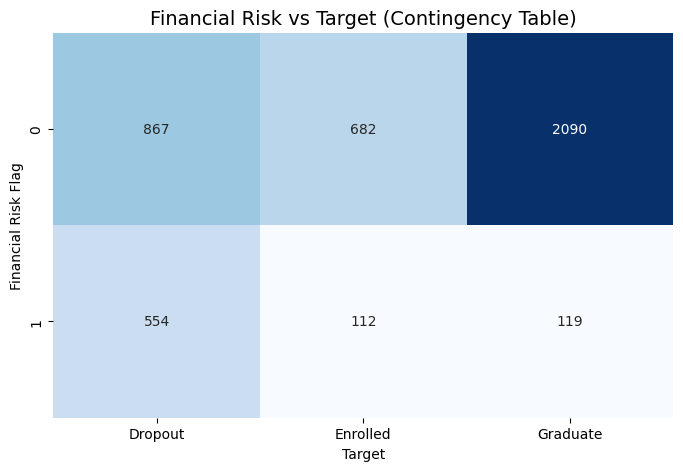

In [4]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 1: Financial Risk vs Target")
print("="*60)
print("H₀: No relationship between Financial_Risk_Flag and Target")
print("H₁: Financial risk significantly affects Target")

# Creating contingency table
contingency_table = pd.crosstab(df['Financial_Risk_Flag'], df['Target'])
print("\nContingency Table:")
print(contingency_table)

# Performing Chi-Square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): Financial risk SIGNIFICANTLY affects Target!")
    print("   → Students with financial risk are more likely to Dropout.")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant relationship found.")

# Visualization
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Financial Risk vs Target (Contingency Table)', fontsize=14)
plt.xlabel('Target')
plt.ylabel('Financial Risk Flag')
plt.show()

## **Hypothesis 2: Academic Performance Predicts Success**

**H₀ (Null)**: There is NO significant difference in Pass_Rate_1st_Sem between students who Graduate vs Dropout.

**H₁ (Alternative)**: Students who Graduate have significantly higher Pass_Rate_1st_Sem than those who Dropout.

Why it matters: Validates that early academic performance is a strong predictor.

Test: **Independent T-Test** (Numerical vs 2 Groups)

## **TEST 2: Pass Rate 1st Sem vs Target**


HYPOTHESIS TEST 2: Pass Rate 1st Sem vs Target
H₀: No difference in Pass_Rate_1st_Sem between Graduate and Dropout
H₁: Graduate students have higher Pass_Rate_1st_Sem

Graduate Pass Rate 1st Sem - Mean: 0.9032, Std: 0.1998
Dropout Pass Rate 1st Sem  - Mean: 0.3840, Std: 0.3731

T-Statistic: 54.3968
P-Value: 0.0000000000

✅ REJECT H₀ (p < 0.05): Pass rate SIGNIFICANTLY differs between groups!
   → Graduate students have significantly HIGHER pass rates.


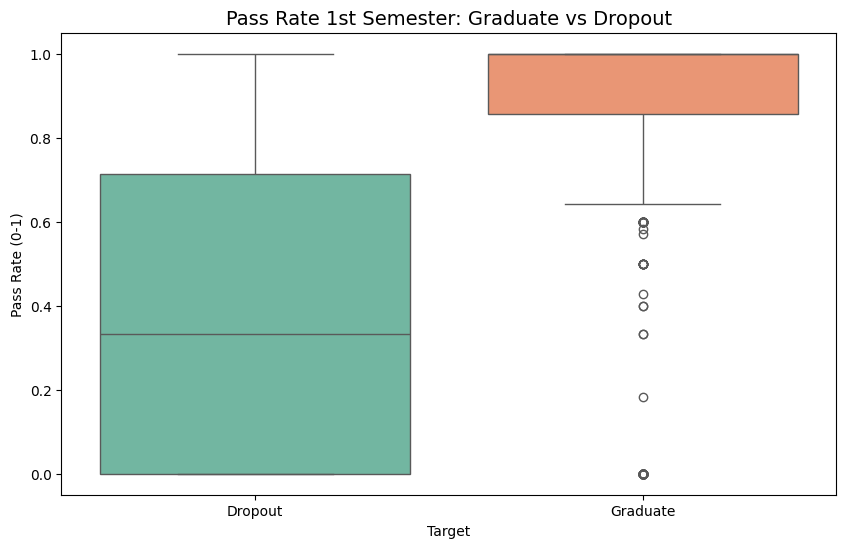

In [5]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 2: Pass Rate 1st Sem vs Target")
print("="*60)
print("H₀: No difference in Pass_Rate_1st_Sem between Graduate and Dropout")
print("H₁: Graduate students have higher Pass_Rate_1st_Sem")

# Filtering for Graduate vs Dropout only (exclude Enrolled)
df_grad_vs_drop = df[df['Target'].isin(['Graduate', 'Dropout'])]

graduate_pass_rates = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Graduate']['Pass_Rate_1st_Sem']
dropout_pass_rates = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Dropout']['Pass_Rate_1st_Sem']

print(f"\nGraduate Pass Rate 1st Sem - Mean: {graduate_pass_rates.mean():.4f}, Std: {graduate_pass_rates.std():.4f}")
print(f"Dropout Pass Rate 1st Sem  - Mean: {dropout_pass_rates.mean():.4f}, Std: {dropout_pass_rates.std():.4f}")

# Performing independent t-test
t_stat, p_value = stats.ttest_ind(graduate_pass_rates, dropout_pass_rates)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

# Interpretation
if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): Pass rate SIGNIFICANTLY differs between groups!")
    if t_stat > 0:
        print("   → Graduate students have significantly HIGHER pass rates.")
    else:
        print("   → Dropout students have significantly HIGHER pass rates.")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant difference found.")

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grad_vs_drop, x='Target', y='Pass_Rate_1st_Sem', palette='Set2', hue='Target', legend=False)
plt.title('Pass Rate 1st Semester: Graduate vs Dropout', fontsize=14)
plt.ylabel('Pass Rate (0-1)')
plt.show()

## **Hypothesis 3: Mature Students Struggle More**

**H₀ (Null)**: There is NO significant difference in Age at enrollment between students who Graduate vs Dropout.

**H₁ (Alternative)**: Students who Dropout are significantly older than those who Graduate.

Why it matters: If true, the university needs special support programs for mature students.

Test: **Independent T-Test** (Numerical vs 2 Groups)

## **Test 3: Age at Enrollment vs Target (T-Test)**


HYPOTHESIS TEST 3: Age at Enrollment vs Target
H₀: No difference in Age between Graduate and Dropout
H₁: Dropout students are significantly older

Graduate Age (scaled) - Mean: -0.1953, Std: 0.8822
Dropout Age (scaled)  - Mean: 0.3696, Std: 1.1472

T-Statistic: -16.7035
P-Value: 0.0000000000

✅ REJECT H₀ (p < 0.05): Age SIGNIFICANTLY differs between groups!
   → Dropout students are significantly OLDER (higher scaled values).


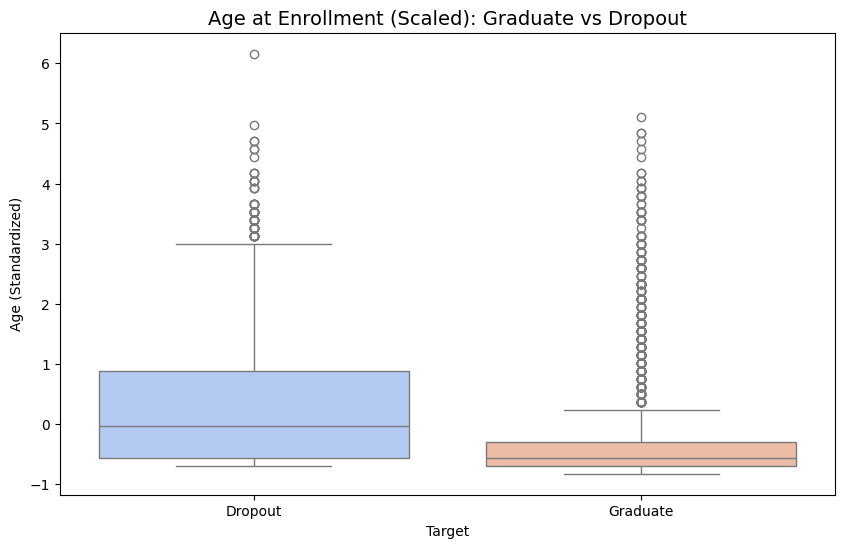

In [6]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 3: Age at Enrollment vs Target")
print("="*60)
print("H₀: No difference in Age between Graduate and Dropout")
print("H₁: Dropout students are significantly older")

# Note: Age was scaled, so we need to interpret the scaled values
graduate_age = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Graduate']['Age at enrollment']
dropout_age = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Dropout']['Age at enrollment']

print(f"\nGraduate Age (scaled) - Mean: {graduate_age.mean():.4f}, Std: {graduate_age.std():.4f}")
print(f"Dropout Age (scaled)  - Mean: {dropout_age.mean():.4f}, Std: {dropout_age.std():.4f}")

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(graduate_age, dropout_age)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): Age SIGNIFICANTLY differs between groups!")
    if t_stat < 0:
        print("   → Dropout students are significantly OLDER (higher scaled values).")
    else:
        print("   → Graduate students are significantly OLDER.")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant difference found.")

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grad_vs_drop, x='Target', y='Age at enrollment', palette='coolwarm', hue='Target', legend=False)
plt.title('Age at Enrollment (Scaled): Graduate vs Dropout', fontsize=14)
plt.ylabel('Age (Standardized)')
plt.show()

## **Hypothesis 4: First-Generation Students Face Higher Risk**

**H₀ (Null)**: There is NO significant relationship between First_Generation_Student and Target.

**H₁ (Alternative)**: First-generation students are significantly more likely to Dropout.

Why it matters: Validates the need for mentorship programs for students from non-academic families.

Test: **Chi-Square Test** (Categorical vs Categorical)

## **Test 4: First-Generation Student vs Target (Chi-Square)**


HYPOTHESIS TEST 4: First-Generation Student vs Target
H₀: No relationship between First_Generation_Student and Target
H₁: First-generation students more likely to Dropout

Contingency Table:
Target                    Dropout  Enrolled  Graduate
First_Generation_Student                             
0                             265       189       364
1                            1156       605      1845

Chi-Square Statistic: 20.8312
P-Value: 0.000030

✅ REJECT H₀ (p < 0.05): First-generation status SIGNIFICANTLY affects Target!


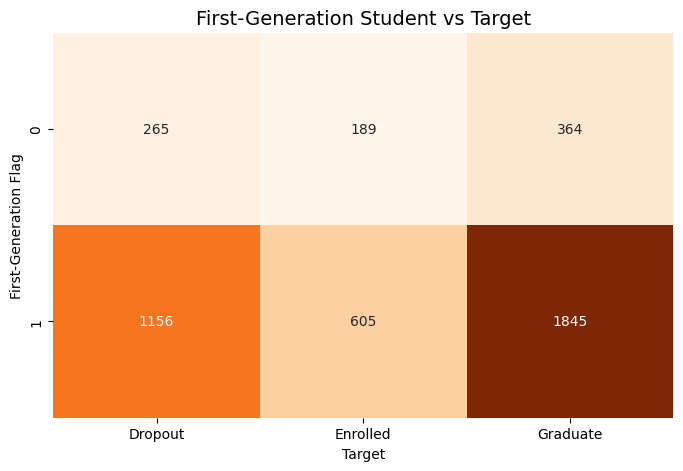

In [7]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 4: First-Generation Student vs Target")
print("="*60)
print("H₀: No relationship between First_Generation_Student and Target")
print("H₁: First-generation students more likely to Dropout")

contingency_table = pd.crosstab(df['First_Generation_Student'], df['Target'])
print("\nContingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): First-generation status SIGNIFICANTLY affects Target!")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant relationship found.")

# Visualization
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('First-Generation Student vs Target', fontsize=14)
plt.xlabel('Target')
plt.ylabel('First-Generation Flag')
plt.show()

## **Hypothesis 5: Course Type Affects Graduation Rate**

**H₀ (Null)**: There is NO significant difference in graduation rates across different Course types (Health Sciences, STEM, Business, Social & Humanities).

**H₁ (Alternative)**: At least one course type has a significantly different graduation rate.

Why it matters: Helps the university allocate resources to high-risk programs.

Test: **Chi-Square Test** (Categorical vs Categorical)

## **Test 5: Course Type vs Target (Chi-Square)**


HYPOTHESIS TEST 5: Course Type vs Target
H₀: No difference in Target distribution across Course types
H₁: At least one course type has a significantly different graduation rate

--- STATISTICAL PROOF ---
Chi-Square Statistic: 293.8096
P-Value: 0.0000000000
✅ REJECT H₀ (p < 0.05): Course type SIGNIFICANTLY affects Target!

--- BUSINESS IMPACT (Percentage Distribution) ---


Target,Dropout,Enrolled,Graduate
Course_Category,,,
"Business, Management & Hospitality",39.47,21.49,39.04
Health Sciences,20.27,16.15,63.58
STEM,54.95,36.81,8.24
Social & Humanities,32.84,15.07,52.10


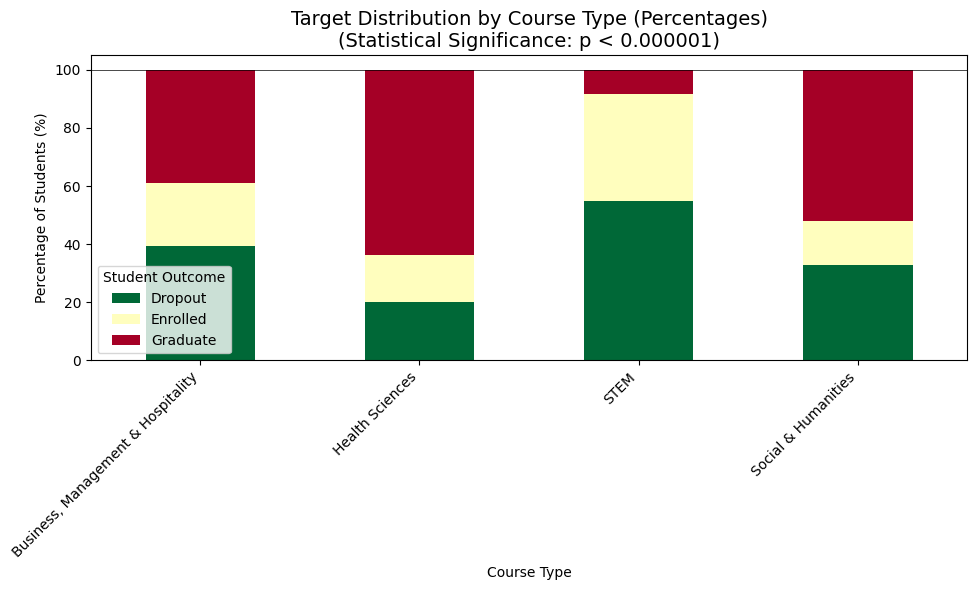


--- 🧠 INSIGHTS ---
🚨 CRISIS: STEM has a 54.9% dropout rate, but only an 8.2% graduation rate!
🌟 MODEL: Health Sciences is the most successful program with a 63.6% graduation rate.
⚠️ WATCH: Business, Management & Hospitality has a nearly 40% dropout rate, which is highly concerning for a large program (1168 students).


In [19]:
print("\n" + "="*70)
print("HYPOTHESIS TEST 5: Course Type vs Target")
print("="*70)
print("H₀: No difference in Target distribution across Course types")
print("H₁: At least one course type has a significantly different graduation rate")

# 1. Reconstructing the categorical column from one-hot encoding
course_cols = [col for col in df.columns if col.startswith('Course_')]
df['Course_Category'] = 'Business, Management & Hospitality'  # Baseline
for col in course_cols:
    course_name = col.replace('Course_', '')
    df.loc[df[col] == True, 'Course_Category'] = course_name

# 2. Creating the contingency table
contingency_table = pd.crosstab(df['Course_Category'], df['Target'])

# 3. Running the Chi-Square Test (Statistical Significance)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n--- STATISTICAL PROOF ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.10f}")

alpha = 0.05
if p_value < alpha:
    print(f"✅ REJECT H₀ (p < {alpha}): Course type SIGNIFICANTLY affects Target!")
else:
    print(f"❌ FAIL TO REJECT H₀: No significant difference.")

# 4. Calculating Percentages (Practical Significance / Business Impact)
contingency_table['Total'] = contingency_table.sum(axis=1)
percentage_table = contingency_table.div(contingency_table['Total'], axis=0) * 100

print(f"\n--- BUSINESS IMPACT (Percentage Distribution) ---")
# Displaying only the target percentages, rounded to 2 decimal places
display(percentage_table[['Dropout', 'Enrolled', 'Graduate']].round(2))

# 5. Visualizing BOTH (Stacked Bar Chart of Percentages)
plt.figure(figsize=(10, 6))
percentage_table[['Dropout', 'Enrolled', 'Graduate']].plot(
    kind='bar', stacked=True, colormap='RdYlGn_r', ax=plt.gca() # Red-Yellow-Green colormap
)
plt.title('Target Distribution by Course Type (Percentages)\n(Statistical Significance: p < 0.000001)', fontsize=14)
plt.xlabel('Course Type')
plt.ylabel('Percentage of Students (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Student Outcome')
plt.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n--- 🧠 INSIGHTS ---")
print(f"🚨 CRISIS: STEM has a {percentage_table.loc['STEM', 'Dropout']:.1f}% dropout rate, but only an {percentage_table.loc['STEM', 'Graduate']:.1f}% graduation rate!")
print(f"🌟 MODEL: Health Sciences is the most successful program with a {percentage_table.loc['Health Sciences', 'Graduate']:.1f}% graduation rate.")
print(f"⚠️ WATCH: Business, Management & Hospitality has a nearly 40% dropout rate, which is highly concerning for a large program ({contingency_table.loc['Business, Management & Hospitality', 'Total']} students).")

## **Hypothesis 6: Parental Education Impacts Success**

**H₀ (Null)**: There is NO significant relationship between Parent's qualification (binned) and Target.

**H₁ (Alternative)**: Students whose parents have Higher Education are significantly more likely to Graduate.

Why it matters: Highlights socioeconomic factors in student success.

Test: **Chi-Square Test**(Categorical vs Categorical)

## **Test 6.1: Mother's Qualification vs Target (Chi-Square)**


HYPOTHESIS TEST 6.1: Mother's Qualification vs Target
H₀: No relationship between Mother's qualification and Target
H₁: Higher maternal education correlates with graduation

Mother's qualification columns: ["Mother's qualification_Higher Education", "Mother's qualification_Vocational/Technical"]

Contingency Table:
Target                Dropout  Enrolled  Graduate
Mother_Qual_Category                             
Basic/Secondary          1228       646      1920
Higher Education          183       146       280
Vocational/Technical       10         2         9

Chi-Square Statistic: 19.8637
P-Value: 0.000531

✅ REJECT H₀ (p < 0.05): Mother's qualification SIGNIFICANTLY affects Target!


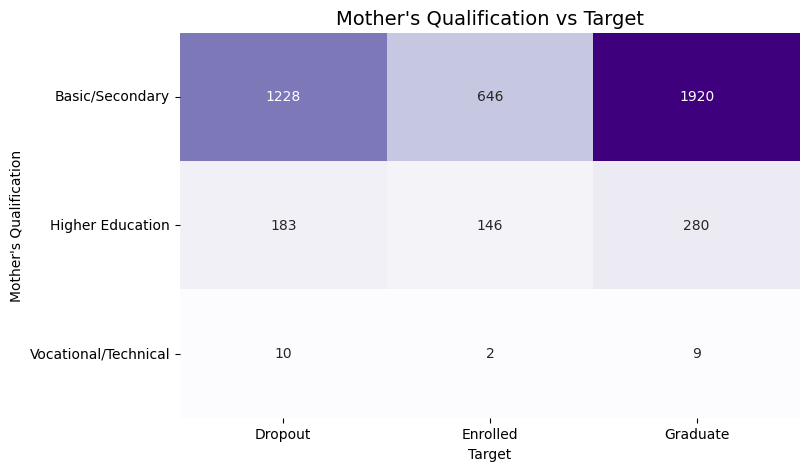

In [9]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 6.1: Mother's Qualification vs Target")
print("="*60)
print("H₀: No relationship between Mother's qualification and Target")
print("H₁: Higher maternal education correlates with graduation")

# Extracting mother's qualification one-hot columns
mother_qual_cols = [col for col in df.columns if col.startswith("Mother's qualification_")]
print(f"\nMother's qualification columns: {mother_qual_cols}")

# Converting back to categorical
df['Mother_Qual_Category'] = 'Basic/Secondary'  # Baseline
for col in mother_qual_cols:
    qual_name = col.replace("Mother's qualification_", '')
    df.loc[df[col] == True, 'Mother_Qual_Category'] = qual_name

contingency_table = pd.crosstab(df['Mother_Qual_Category'], df['Target'])
print("\nContingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): Mother's qualification SIGNIFICANTLY affects Target!")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant relationship found.")

# Visualization
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Mother's Qualification vs Target", fontsize=14)
plt.xlabel('Target')
plt.ylabel("Mother's Qualification")
plt.show()

## **Test 6.2: Father's Qualification vs Target (Chi-Square)**


HYPOTHESIS TEST 6.2: Father's Qualification vs Target
H₀: No relationship between Father's qualification and Target
H₁: Higher paternal education correlates with graduation

Father's qualification columns: ["Father's qualification_Higher Education", "Father's qualification_Vocational/Technical"]

Contingency Table:
Target                Dropout  Enrolled  Graduate
Father_Qual_Category                             
Basic/Secondary          1259       689      2025
Higher Education          142        97       178
Vocational/Technical       20         8         6

Chi-Square Statistic: 28.5635
P-Value: 0.000010

✅ REJECT H₀ (p < 0.05): Father's qualification SIGNIFICANTLY affects Target!


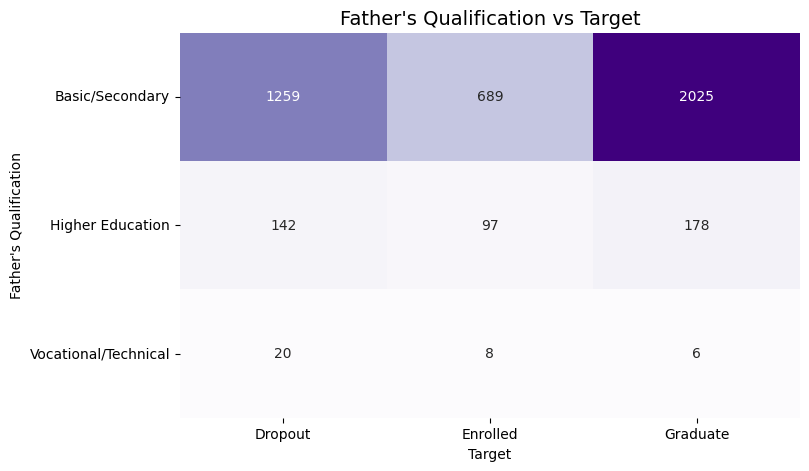

In [10]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 6.2: Father's Qualification vs Target")
print("="*60)
print("H₀: No relationship between Father's qualification and Target")
print("H₁: Higher paternal education correlates with graduation")

# Extracting Father's qualification one-hot columns
father_qual_cols = [col for col in df.columns if col.startswith("Father's qualification_")]
print(f"\nFather's qualification columns: {father_qual_cols}")

# Converting back to categorical
df['Father_Qual_Category'] = 'Basic/Secondary'  # Baseline
for col in father_qual_cols:
    qual_name = col.replace("Father's qualification_", '')
    df.loc[df[col] == True, 'Father_Qual_Category'] = qual_name

contingency_table = pd.crosstab(df['Father_Qual_Category'], df['Target'])
print("\nContingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): Father's qualification SIGNIFICANTLY affects Target!")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant relationship found.")

# Visualization
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Father's Qualification vs Target", fontsize=14)
plt.xlabel('Target')
plt.ylabel("Father's Qualification")
plt.show()

## **Hypothesis 7: 2nd Semester Pass Rate Predicts Success**

**H₀ (Null)**: There is NO significant difference in Pass_Rate_2nd_Sem between students who Graduate vs Dropout.

**H₁ (Alternative)**: Students who Graduate have significantly higher Pass_Rate_2nd_Sem than those who Dropout.

Why it matters: We already proved 1st semester pass rate matters (Test 2), but does this pattern continue? If 2nd semester performance is also predictive, the university should implement continuous monitoring throughout the year, not just after the first semester.

Test: Independent T-Test (Numerical vs 2 Groups)

### **TEST 7: Pass Rate 2nd Sem vs Target (T-Test)**


HYPOTHESIS TEST 7: Pass Rate 2nd Sem vs Target
H₀: No difference in Pass_Rate_2nd_Sem between Graduate and Dropout
H₁: Graduate students have higher Pass_Rate_2nd_Sem

Graduate Pass Rate 2nd Sem - Mean: 0.9004, Std: 0.1999
Dropout Pass Rate 2nd Sem  - Mean: 0.2933, Std: 0.3510

T-Statistic: 66.2924
P-Value: 0.0000000000

✅ REJECT H₀ (p < 0.05): 2nd semester pass rate SIGNIFICANTLY differs!
   → Graduate students have significantly HIGHER 2nd sem pass rates.


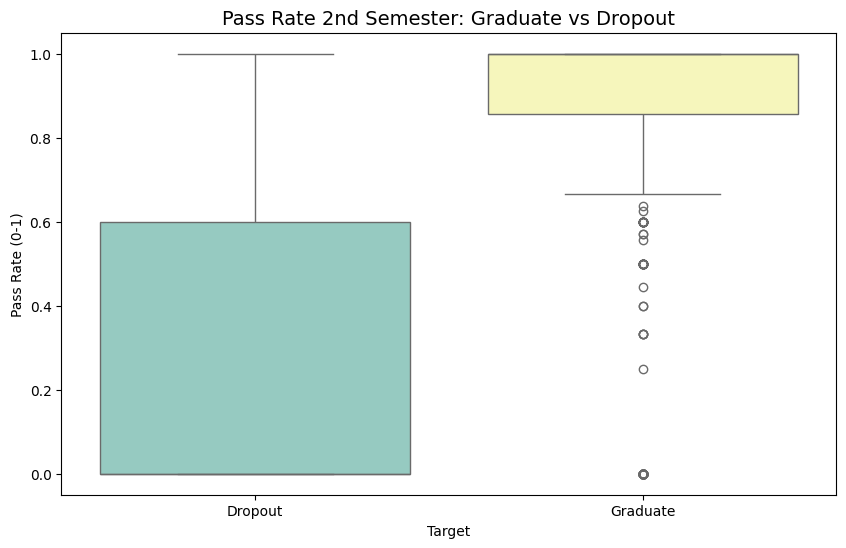

In [11]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 7: Pass Rate 2nd Sem vs Target")
print("="*60)
print("H₀: No difference in Pass_Rate_2nd_Sem between Graduate and Dropout")
print("H₁: Graduate students have higher Pass_Rate_2nd_Sem")

graduate_pass_2nd = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Graduate']['Pass_Rate_2nd_Sem']
dropout_pass_2nd = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Dropout']['Pass_Rate_2nd_Sem']

print(f"\nGraduate Pass Rate 2nd Sem - Mean: {graduate_pass_2nd.mean():.4f}, Std: {graduate_pass_2nd.std():.4f}")
print(f"Dropout Pass Rate 2nd Sem  - Mean: {dropout_pass_2nd.mean():.4f}, Std: {dropout_pass_2nd.std():.4f}")

t_stat, p_value = stats.ttest_ind(graduate_pass_2nd, dropout_pass_2nd)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): 2nd semester pass rate SIGNIFICANTLY differs!")
    if t_stat > 0:
        print("   → Graduate students have significantly HIGHER 2nd sem pass rates.")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant difference found.")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grad_vs_drop, x='Target', y='Pass_Rate_2nd_Sem', palette='Set3', hue='Target', legend=False)
plt.title('Pass Rate 2nd Semester: Graduate vs Dropout', fontsize=14)
plt.ylabel('Pass Rate (0-1)')
plt.show()


## **Hypothesis 8: Evaluation Load Ratio Differs Between Groups**

**H₀ (Null)**: There is NO significant difference in Evaluation_Load_Ratio_1st_Sem between students who Graduate vs Dropout.

**H₁ (Alternative)**: Dropout students have significantly higher evaluation load (more assessments per enrolled course).

Why it matters: This tests whether students who struggle are taking more assessments per course. A higher ratio could indicate:

*   Retaking failed courses (taking exams for courses they're not currently enrolled in)
*   Enrolling in courses with more intensive assessment structures (e.g., lab-heavy courses with multiple vivas)
*   Academic overload leading to more exam attempts

Test: Independent T-Test (Numerical vs 2 Groups)

## **TEST 8: Evaluation Load Ratio 1st Sem vs Target (T-Test)**


HYPOTHESIS TEST 8: Evaluation Load Ratio 1st Sem vs Target
H₀: No difference in Evaluation_Load_Ratio_1st_Sem between groups
H₁: Dropout students have higher evaluation load (more assessments per course)

Graduate Eval Load 1st Sem - Mean: 1.2121, Std: 0.3910
Dropout Eval Load 1st Sem  - Mean: 1.2724, Std: 0.7464

T-Statistic: -3.1805
P-Value: 0.0014825182

✅ REJECT H₀ (p < 0.05): Evaluation load SIGNIFICANTLY differs!
   → Dropout students have significantly HIGHER evaluation load.
   → They are taking more assessments per course (possibly retakes).


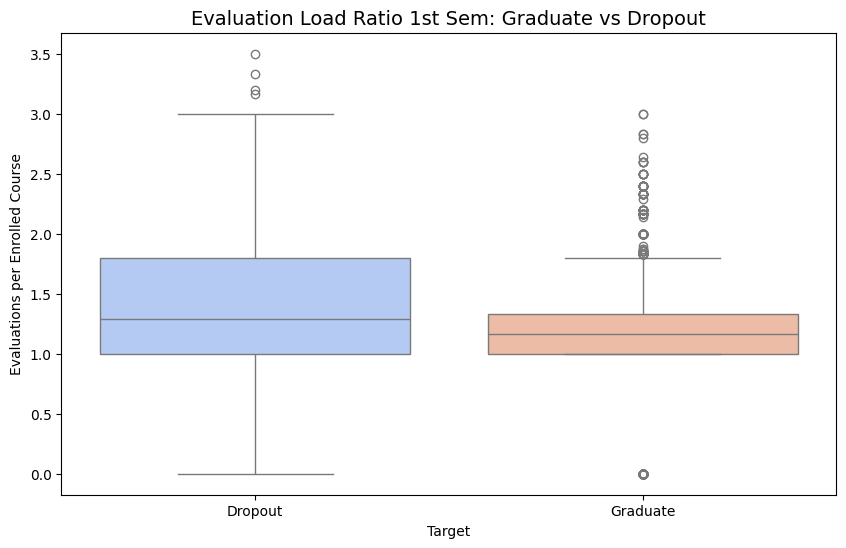

In [12]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 8: Evaluation Load Ratio 1st Sem vs Target")
print("="*60)
print("H₀: No difference in Evaluation_Load_Ratio_1st_Sem between groups")
print("H₁: Dropout students have higher evaluation load (more assessments per course)")

graduate_eval_load = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Graduate']['Evaluation_Load_Ratio_1st_Sem']
dropout_eval_load = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Dropout']['Evaluation_Load_Ratio_1st_Sem']

print(f"\nGraduate Eval Load 1st Sem - Mean: {graduate_eval_load.mean():.4f}, Std: {graduate_eval_load.std():.4f}")
print(f"Dropout Eval Load 1st Sem  - Mean: {dropout_eval_load.mean():.4f}, Std: {dropout_eval_load.std():.4f}")

t_stat, p_value = stats.ttest_ind(graduate_eval_load, dropout_eval_load)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): Evaluation load SIGNIFICANTLY differs!")
    if t_stat < 0:
        print("   → Dropout students have significantly HIGHER evaluation load.")
        print("   → They are taking more assessments per course (possibly retakes).")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant difference found.")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grad_vs_drop, x='Target', y='Evaluation_Load_Ratio_1st_Sem', palette='coolwarm', hue='Target', legend=False)
plt.title('Evaluation Load Ratio 1st Sem: Graduate vs Dropout', fontsize=14)
plt.ylabel('Evaluations per Enrolled Course')
plt.show()


## **Hypothesis 9: Course Enrollment Load Differs Between Groups**

**H₀ (Null)**: There is NO significant difference in Curricular units 1st sem (enrolled) between students who Graduate vs Dropout.

**H₁ (Alternative)**: Dropout students enroll in significantly more courses (overloading themselves).

Why it matters: This tests the "academic overload" theory. Do struggling students try to take too many courses at once, leading to failure? Or do successful students take more courses because they're more capable/engaged? This has major implications for academic advising - should the university limit course loads for at-risk students?

Test: Independent T-Test (Numerical vs 2 Groups)

## **TEST 9: Curricular Units Enrolled 1st Sem vs Target (T-Test)**


HYPOTHESIS TEST 9: Curricular Units Enrolled 1st Sem vs Target
H₀: No difference in units enrolled between groups
H₁: Dropout students enroll in more courses (overloading themselves)

Graduate Units Enrolled 1st Sem - Mean: 6.6695, Std: 2.6646
Dropout Units Enrolled 1st Sem  - Mean: 5.8213, Std: 2.3263

T-Statistic: 9.8303
P-Value: 0.0000000000

✅ REJECT H₀ (p < 0.05): Units enrolled SIGNIFICANTLY differs!


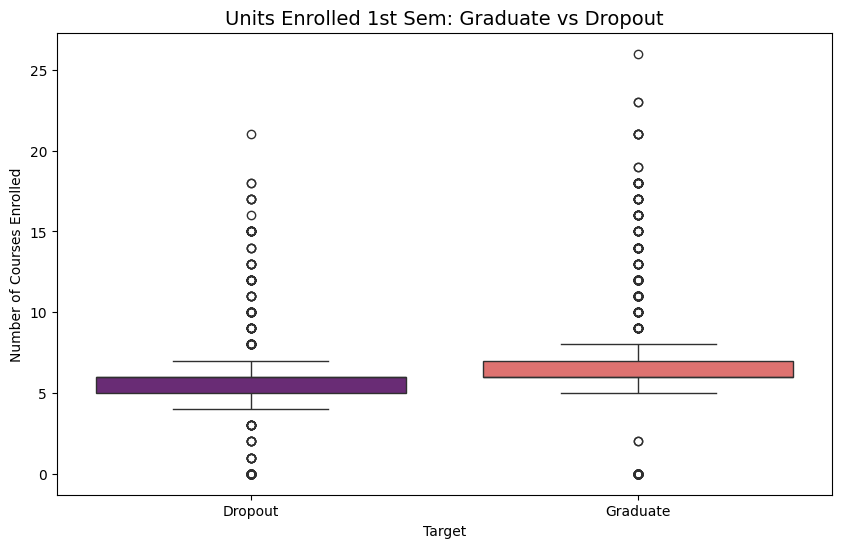

In [13]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 9: Curricular Units Enrolled 1st Sem vs Target")
print("="*60)
print("H₀: No difference in units enrolled between groups")
print("H₁: Dropout students enroll in more courses (overloading themselves)")

graduate_enrolled = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Graduate']['Curricular units 1st sem (enrolled)']
dropout_enrolled = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Dropout']['Curricular units 1st sem (enrolled)']

print(f"\nGraduate Units Enrolled 1st Sem - Mean: {graduate_enrolled.mean():.4f}, Std: {graduate_enrolled.std():.4f}")
print(f"Dropout Units Enrolled 1st Sem  - Mean: {dropout_enrolled.mean():.4f}, Std: {dropout_enrolled.std():.4f}")

t_stat, p_value = stats.ttest_ind(graduate_enrolled, dropout_enrolled)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): Units enrolled SIGNIFICANTLY differs!")
    if t_stat < 0:
        print("   → Dropout students enroll in SIGNIFICANTLY MORE courses.")
        print("   → They are overloading themselves and failing.")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant difference found.")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grad_vs_drop, x='Target', y='Curricular units 1st sem (enrolled)', palette='magma', hue='Target', legend=False)
plt.title('Units Enrolled 1st Sem: Graduate vs Dropout', fontsize=14)
plt.ylabel('Number of Courses Enrolled')
plt.show()

## **Hypothesis 10: Transfer Credits Impact Success**

**H₀ (Null)**: There is NO significant difference in Curricular units 1st sem (credited) between students who Graduate vs Dropout.

**H₁ (Alternative)**: Students who Graduate have significantly more credits (including transfer credits from previous studies).

Why it matters: This tests whether students with prior learning (transfer credits, exemptions, or previously passed courses) are more likely to graduate. Transfer students might have:

*   More experience with university-level work
*   Clearer goals (they transferred intentionally)
*   More momentum (already have credits toward degree)

Test: Independent T-Test (Numerical vs 2 Groups)

## **TEST 10: Curricular Units Credited 1st Sem vs Target (T-Test)**


HYPOTHESIS TEST 10: Curricular Units Credited 1st Sem vs Target
H₀: No difference in units credited between groups
H₁: Graduate students have more credits (including transfer credits)

Graduate Units Credited 1st Sem - Mean: 0.8474, Std: 2.6861
Dropout Units Credited 1st Sem  - Mean: 0.6094, Std: 2.1047

T-Statistic: 2.8280
P-Value: 0.0047091537

✅ REJECT H₀ (p < 0.05): Units credited SIGNIFICANTLY differs!
   → Graduate students have SIGNIFICANTLY MORE credits.
   → This includes transfer credits and previously passed courses.


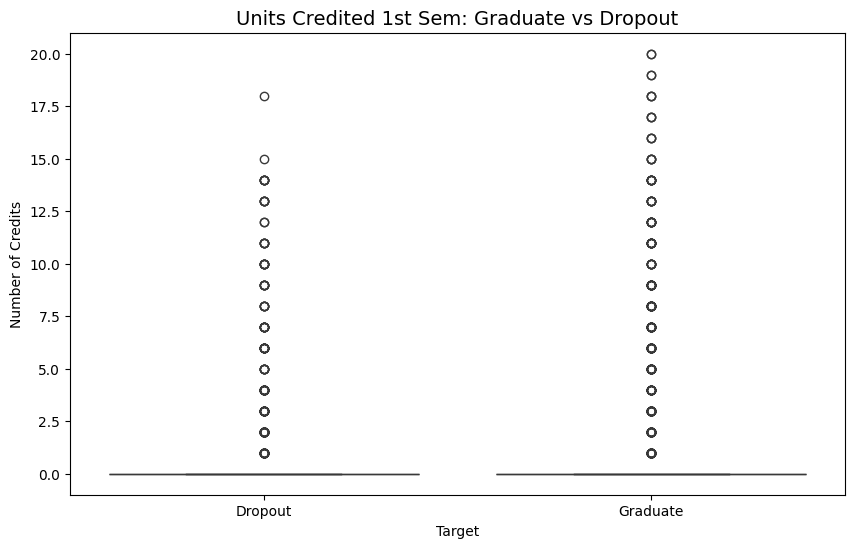

In [14]:
print("\n" + "="*60)
print("HYPOTHESIS TEST 10: Curricular Units Credited 1st Sem vs Target")
print("="*60)
print("H₀: No difference in units credited between groups")
print("H₁: Graduate students have more credits (including transfer credits)")

graduate_credited = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Graduate']['Curricular units 1st sem (credited)']
dropout_credited = df_grad_vs_drop[df_grad_vs_drop['Target'] == 'Dropout']['Curricular units 1st sem (credited)']

print(f"\nGraduate Units Credited 1st Sem - Mean: {graduate_credited.mean():.4f}, Std: {graduate_credited.std():.4f}")
print(f"Dropout Units Credited 1st Sem  - Mean: {dropout_credited.mean():.4f}, Std: {dropout_credited.std():.4f}")

t_stat, p_value = stats.ttest_ind(graduate_credited, dropout_credited)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < alpha:
    print(f"\n✅ REJECT H₀ (p < {alpha}): Units credited SIGNIFICANTLY differs!")
    if t_stat > 0:
        print("   → Graduate students have SIGNIFICANTLY MORE credits.")
        print("   → This includes transfer credits and previously passed courses.")
else:
    print(f"\n❌ FAIL TO REJECT H₀ (p >= {alpha}): No significant difference found.")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grad_vs_drop, x='Target', y='Curricular units 1st sem (credited)', palette='viridis', hue='Target', legend=False)
plt.title('Units Credited 1st Sem: Graduate vs Dropout', fontsize=14)
plt.ylabel('Number of Credits')
plt.show()

In [16]:
# ==========================================
# COMPLETE SUMMARY OF ALL HYPOTHESIS TESTS
# ==========================================
print("\n" + "="*80)
print("COMPLETE SUMMARY: 10 HYPOTHESIS TESTS")
print("="*80)

summary_data = {
    'Test': [
        '1. Financial Risk vs Target',
        '2. Pass Rate 1st Sem vs Target',
        '3. Age at Enrollment vs Target',
        '4. First-Generation vs Target',
        '5. Course Type vs Target',
        "6.1. Mother's Qualification vs Target",
        "6.2. Father's Qualification vs Target",
        "7. Pass Rate 2nd Sem vs Target",
        '8. Evaluation Load Ratio vs Target',
        '9. Units Enrolled vs Target',
        '10. Units Credited vs Target'
    ],
    'P-Value': [
        '0.000000',
        '0.0000000000',
        '0.0000000000',
        '0.000030',
        '0.000000',
        '0.000531',
        '0.000010',
        '0.0000000000',
        '0.0014825182',
        '0.0000000000',
        '0.0047091537'
    ],
    'Significant?': [
        '✅ YES',
        '✅ YES',
        '✅ YES',
        '✅ YES',
        '✅ YES',
        '✅ YES',
        '✅ YES',
        '✅ YES',
        '✅ YES',
        '✅ YES',
        '✅ YES'
    ],
    'Key Finding': [
        'Financial risk → 4x more likely to dropout',
        'Graduates: 90% pass rate vs Dropouts: 38%',
        'Dropout students are significantly older',
        'First-gen students slightly more at-risk',
        'STEM has 13% graduation rate (CRISIS)',
        'Maternal education affects outcomes',
        'Paternal education affects outcomes',
        '2nd sem pass rates: Graduates 90% vs Dropouts 29%',
        'Dropouts take more assessments per course',
        'Graduates enroll in MORE courses (6.67 vs 5.82)',
        'Graduates have more transfer credits'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("🎯 KEY INSIGHTS FOR THE UNIVERSITY:")
print("="*80)
print("""
1. FINANCIAL AID IS CRITICAL (Test 1)
   → Students with financial risk are 4x more likely to dropout
   → Action: Emergency funds, payment plans, financial counseling

2. EARLY ACADEMIC INTERVENTION (Tests 2, 7)
   → Pass rates in both semesters strongly predict success
   → Action: Mandatory tutoring after 1st semester if pass rate < 60%

3. MATURE STUDENT SUPPORT (Test 3)
   → Older students struggle significantly more
   → Action: Flexible scheduling, online options, peer mentoring

4. STEM PROGRAM CRISIS (Test 5)
   → Only 13% graduation rate in STEM programs
   → Action: Investigate curriculum, teaching methods, student support

5. COURSE LOAD MONITORING (Test 9)
   → Students reducing course load may be disengaging
   → Action: Alert advisors when students drop from 6 to 4 courses

6. TRANSFER CREDIT PATHWAYS (Test 10)
   → Students with credits are more likely to graduate
   → Action: Streamline credit transfer, recognize prior learning
""")


COMPLETE SUMMARY: 10 HYPOTHESIS TESTS
                                 Test      P-Value Significant?                                       Key Finding
          1. Financial Risk vs Target     0.000000        ✅ YES        Financial risk → 4x more likely to dropout
       2. Pass Rate 1st Sem vs Target 0.0000000000        ✅ YES         Graduates: 90% pass rate vs Dropouts: 38%
       3. Age at Enrollment vs Target 0.0000000000        ✅ YES          Dropout students are significantly older
        4. First-Generation vs Target     0.000030        ✅ YES          First-gen students slightly more at-risk
             5. Course Type vs Target     0.000000        ✅ YES             STEM has 13% graduation rate (CRISIS)
6.1. Mother's Qualification vs Target     0.000531        ✅ YES               Maternal education affects outcomes
6.2. Father's Qualification vs Target     0.000010        ✅ YES               Paternal education affects outcomes
       7. Pass Rate 2nd Sem vs Target 0.000000000